# **CESM**
Below are some (hopefully) helpful examples and code cells!

## **Initial Set Up-related**

### Imports

In [24]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
import scipy.ndimage as ndi

########## Xarray ##########
import xarray as xr

### Path Definitions

In [25]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [26]:
# Creates a list of atmospheric variables
atm_vars = ['TS','TREFHT','ICEFRAC']

### Dictionary Definitions

In [27]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [28]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        # ds_temp_atm_short = ds_temp_atm.isel(time=slice(11,12*15-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm)

        # Deletes the temporary data sets
        del ds_temp_atm#, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Spin up**

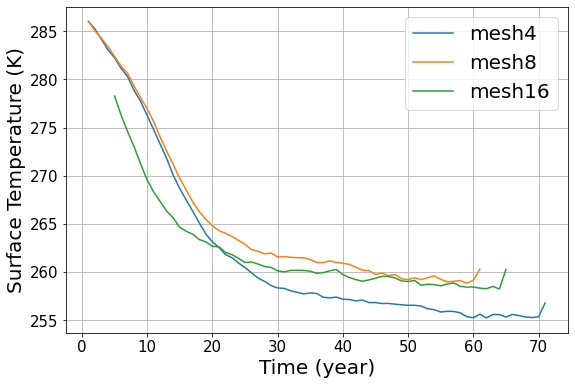

In [29]:
# Overall: plots the evolution of the average surface temperature for each plot over time

plt.figure(figsize=(9,6))

for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['TS']

    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case['TS'].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon'))

    plt.plot(gm.year,gm,label=case)

plt.xlabel('Time (year)',fontsize=20)
plt.ylabel('Surface Temperature (K)',fontsize=20)
plt.tick_params(labelsize=15)
plt.grid()
plt.legend(fontsize=20)

plt.show()
plt.close()

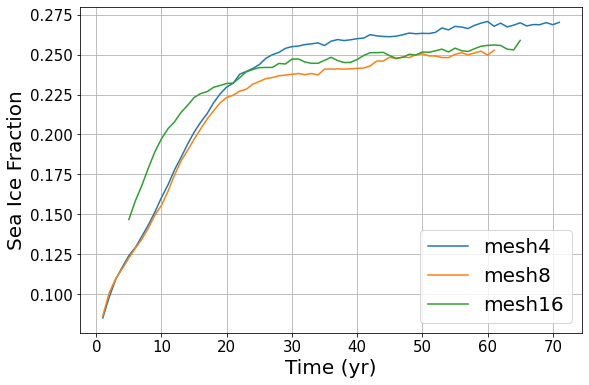

In [30]:
# Overall: plots the evolution of the average sea-ice fraction for each plot over time

plt.figure(figsize=(9,6))

for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['ICEFRAC']

    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case['ICEFRAC'].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon'))

    plt.plot(gm.year,gm,label=case)

plt.xlabel('Time (yr)',fontsize=20)
plt.ylabel('Sea Ice Fraction',fontsize=20)
plt.tick_params(labelsize=15)
plt.grid()
plt.legend(fontsize=20)

plt.show()
plt.close()

# **After Stabilisation**
Re-import the data from the storage cluster

In [31]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 30
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


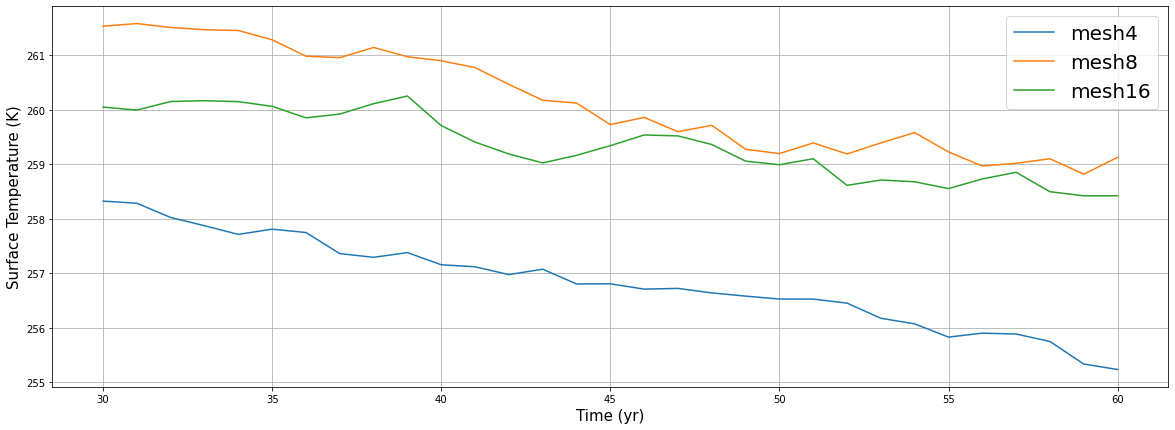

In [32]:
# Overall: plots the evolution of the average surface temperature for each plot over time after the spin up

plt.figure(figsize=(20,7))

for case in config:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['TS']

    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case['TS'].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon'))

    plt.plot(gm.year,gm,label=case)

plt.xlabel('Time (yr)',fontsize=15)
plt.ylabel('Surface Temperature (K)',fontsize=15)
plt.grid()
plt.legend(fontsize=20)

plt.show()
plt.close()